Lasso (L1) MSE: 1653927022.2725523
Ridge (L2) MSE: 1616801393.4551332


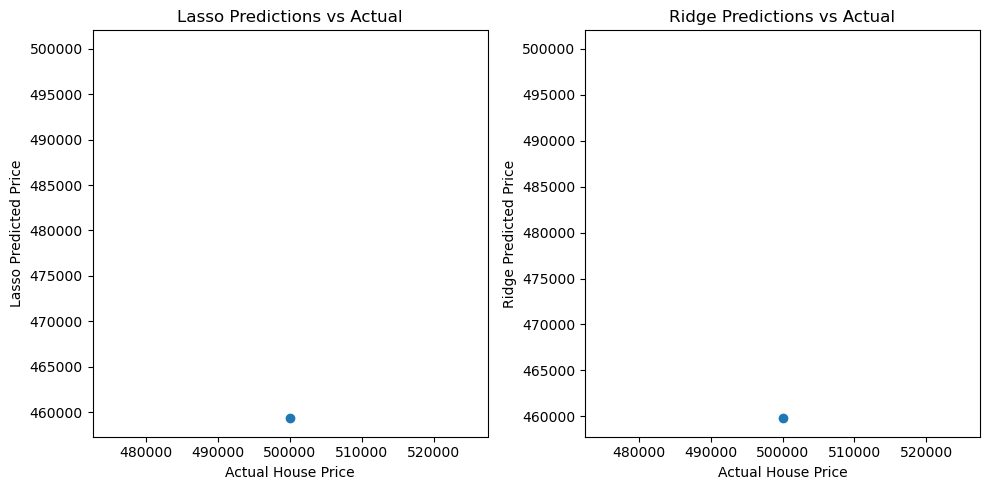

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Sample dataset
data = {
    'house_size': [1500, 1800, 2400, 3000, 3500],  # Square footage of the house
    'bedrooms': [3, 4, 3, 5, 4],  # Number of bedrooms
    'house_price': [400000, 500000, 600000, 700000, 800000]  # Cost of the house
}

# Create DataFrame
df = pd.DataFrame(data)

# Define features and target
X = df[['house_size', 'bedrooms']]
y = df['house_price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models with regularization
lasso = Lasso(alpha=0.1)  # L1 regularization (Lasso)
ridge = Ridge(alpha=0.1)  # L2 regularization (Ridge)

# Fit the models
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Predict on the test set
lasso_preds = lasso.predict(X_test)
ridge_preds = ridge.predict(X_test)

# Calculate Mean Squared Error
lasso_mse = mean_squared_error(y_test, lasso_preds)
ridge_mse = mean_squared_error(y_test, ridge_preds)

# Print results
print("Lasso (L1) MSE:", lasso_mse)
print("Ridge (L2) MSE:", ridge_mse)

# Plot the predictions
plt.figure(figsize=(10, 5))

# Actual vs Lasso Predictions
plt.subplot(1, 2, 1)
plt.scatter(y_test, lasso_preds)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Lasso Predictions vs Actual')
plt.xlabel('Actual House Price')
plt.ylabel('Lasso Predicted Price')

# Actual vs Ridge Predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test, ridge_preds)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Ridge Predictions vs Actual')
plt.xlabel('Actual House Price')
plt.ylabel('Ridge Predicted Price')

plt.tight_layout()
plt.show()
